In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline


In [3]:
words=open('names.txt','r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [4]:
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}


In [5]:
block_size=3
def build_dataset(words):
  X=[]
  Y=[]
  for w in words:
    #print(w)
    context=[0]*block_size
    for ch in w +'.':
      ix=stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context),'=>',itos[ix])
      context=context[1:]+[ix]
  X=torch.tensor(X)
  Y=torch.tensor(Y)
  return X,Y
import random
random.seed(42)
random.shuffle(words)
n1=int(0.8*len(words))
n2=int(0.9*len(words))
Xtr,Ytr=build_dataset(words[:n1])
Xdev,Ydev=build_dataset(words[n1:n2])
Xte,Yte=build_dataset(words[n2:])

In [6]:
n_emb=10
n_hidden=200

g=torch.Generator().manual_seed(2147483647)
C=torch.randn((27,n_emb),generator=g)
W1=torch.randn((n_emb*block_size,n_hidden),generator=g)*(5/3)/((n_emb*block_size)**0.5)
#b1=torch.randn(n_hidden,generator=g)*0.01
W2=torch.randn((n_hidden,27),generator=g)*0.01
b2=torch.randn(27,generator=g)*0

bngain=torch.ones((1,n_hidden))
bnbias=torch.zeros((1,n_hidden))
bnmean_running=torch.zeros((1,n_hidden))
bnstd_running=torch.ones((1,n_hidden))

parameters=[C,W1,W2,b2,bngain,bnbias]
for p in parameters:
  p.requires_grad=True


In [7]:
sum(p.nelement() for p in parameters)

12097

In [8]:
#lre=torch.linspace(-3,0,1000)
#lrs=10**lre
stepi=[]
lossi=[]
#lri=[]

In [9]:
for i in range(200000):
  #create minibatch
  ix=torch.randint(0,Xtr.shape[0],(32,))

  #forward pass
  emb=C[Xtr[ix]]
  embcat=emb.view(-1,block_size*n_emb)
  hpreact=embcat@W1 #+b1
  bnstdi=hpreact.std(0,keepdim=True)
  bnmeani=hpreact.mean(0,keepdim=True)
  hpreact=bngain*(hpreact-bnmeani)/bnstdi+bnbias
  with torch.no_grad():
    bnmean_running=0.999*bnmean_running+0.001*bnmeani
    bnstd_running=0.999*bnstd_running+0.001*bnstdi
  h=torch.tanh(hpreact)
  logits=h@W2+b2
  loss=F.cross_entropy(logits,Ytr[ix])
  #backward pass
  for p in parameters:
    p.grad=None
  loss.backward()
  #update
  lr=0.1 if i<100000 else 0.01

  for p in parameters:
    p.data += -lr * p.grad
  #stat calculation
  #lri.append(lre[i])
  lossi.append(loss.log10().item())
  stepi.append(i)
  if i%10000==0:
    print(f'{i:7d}/{200000:7d}: {loss.item():.4f}')

print(loss.item())

      0/ 200000: 3.3145
  10000/ 200000: 2.2195
  20000/ 200000: 2.1499
  30000/ 200000: 2.0990
  40000/ 200000: 2.3163
  50000/ 200000: 2.1754
  60000/ 200000: 2.2040
  70000/ 200000: 2.0747
  80000/ 200000: 2.3496
  90000/ 200000: 1.8079
 100000/ 200000: 1.9613
 110000/ 200000: 1.8702
 120000/ 200000: 2.2828
 130000/ 200000: 2.4069
 140000/ 200000: 1.9256
 150000/ 200000: 1.9748
 160000/ 200000: 2.0562
 170000/ 200000: 2.0095
 180000/ 200000: 2.1571
 190000/ 200000: 1.9974
2.1561601161956787


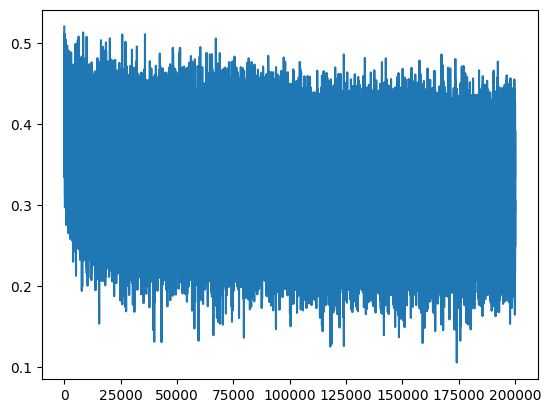

In [10]:
plt.plot(stepi,lossi)

In [11]:
#plt.figure(figsize=(20,10))
#plt.imshow(h.abs()>0.99,cmap='gray',interpolation='nearest')

In [12]:
#plt.hist(hpreact.view(-1).tolist(),50)

In [13]:
#plt.hist(h.view(-1).tolist(),50)

In [14]:
with torch.no_grad():
  emb=C[Xdev]
  embcat=emb.view(-1,block_size*n_emb)
  hpreact=embcat@W1 #+b1
  hpreact=bngain*(hpreact-hpreact.mean(0,keepdim=True))/hpreact.std(0,keepdim=True)+bnbias
  h=torch.tanh(hpreact)
  logits=h@W2+b2
  loss=F.cross_entropy(logits,Ydev)
  print(loss.item())

  emb=C[Xte]
  embcat=emb.view(-1,block_size*n_emb)
  hpreact=embcat@W1 #+b1
  hpreact=bngain*(hpreact-bnmean_running)/bnstd_running+bnbias
  h=torch.tanh(hpreact)
  logits=h@W2+b2
  loss=F.cross_entropy(logits,Yte)
  print(loss.item())

2.1104512214660645
2.1073739528656006


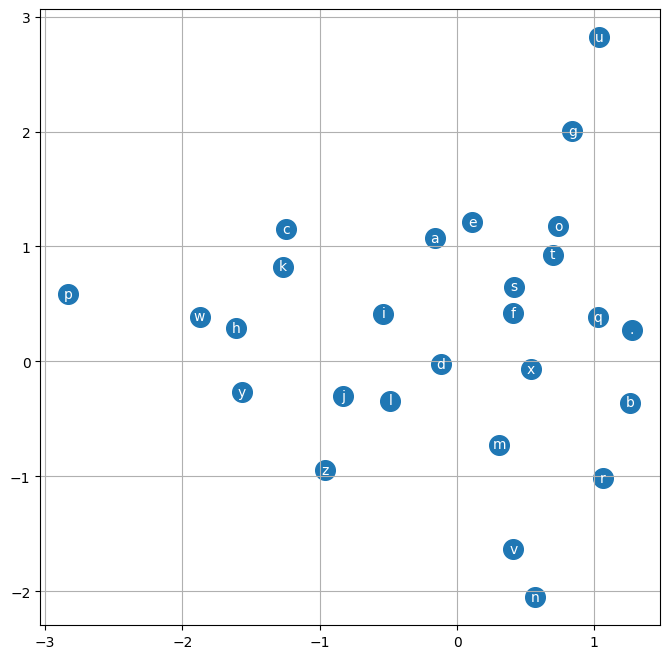

In [15]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data,C[:,1].data,s=200)
for i in range(C.shape[0]):
  plt.text(C[i,0].item(),C[i,1].item(),itos[i],ha='center',va='center',color='white')
plt.grid('minor')

In [17]:
for _ in range(10):

    out = []
    context = [0, 0, 0]

    while True:

        emb = C[torch.tensor([context])]
        embcat = emb.view(1, -1)

        hpreact = embcat @ W1
        hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias

        h = torch.tanh(hpreact)

        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)

        ix = torch.multinomial(
            probs,
            num_samples=1,
            generator=g
        ).item()

        if ix == 0:
            break

        out.append(itos[ix])
        context = context[1:] + [ix]

    print(''.join(out))

city
cetri
ana
lenix
keiana
amarie
wadie
tivin
sten
yanayth
